In [1]:
import pandas as pd 
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error

In [2]:
data = load_diabetes()

In [5]:
df = pd.DataFrame(data=data.data,columns=data.feature_names)

In [7]:
df['Target'] = data.target

In [8]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [9]:
from sklearn.model_selection import train_test_split 

In [10]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('Target',axis=1),df['Target'],random_state=42,test_size=0.15)

In [16]:
lr= LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
pred = lr.predict(x_test)
r2_score(y_test,pred),root_mean_squared_error(y_test,pred)

(0.41472825717435013, 56.544001853073105)

In [20]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import ridge_regression

In [21]:
R = Ridge(alpha=0.0001)
R.fit(x_train,y_train)

,alpha,0.0001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [22]:
pred1 = R.predict(x_test)

In [23]:
r2_score(y_test,pred1),root_mean_squared_error(y_test,pred1)

(0.41486344600350844, 56.53747107572932)

In [29]:
lr.coef_,lr.intercept_

(array([  48.99562671, -259.21326295,  546.14846067,  334.84507667,
        -941.28444386,  523.00153953,  188.08452057,  288.09631074,
         734.4876986 ,   65.97920873]),
 np.float64(151.55985324550707))

In [30]:
R.coef_,lr.intercept_

(array([  49.03591732, -259.14001267,  546.28560694,  334.76309121,
        -929.93670801,  514.15470359,  182.9671148 ,  286.51676458,
         730.16731595,   66.03416094]),
 np.float64(151.55985324550707))

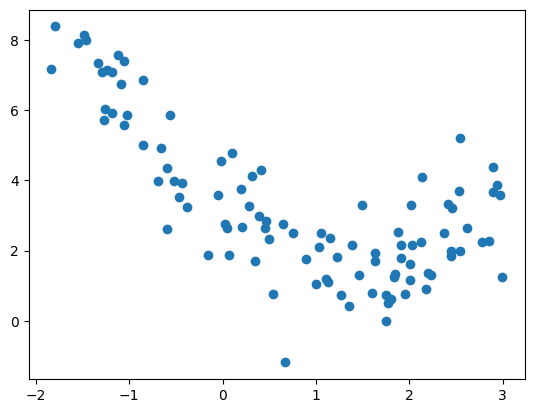

In [33]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

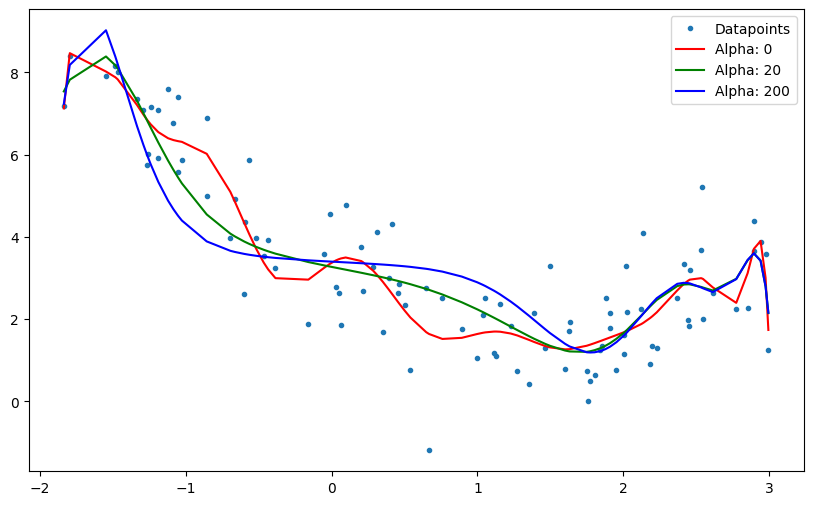

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2,".", label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()